In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


In [2]:
world= yf.download(
    "URTH",
    start="2015-01-01",
    end="2026-09-25",
    auto_adjust=True,
    progress=False,
)

In [3]:
world.head()

Price,Close,High,Low,Open,Volume
Ticker,URTH,URTH,URTH,URTH,URTH
Date,,,,,
2015-01-02,57.947834,58.360305,57.527274,58.360305,31100
2015-01-05,56.589111,57.486838,56.500147,56.783213,61100
2015-01-06,55.836952,56.669976,55.820774,56.661887,16300
2015-01-07,56.403088,56.597195,56.111933,56.265599,19200
2015-01-08,57.656666,57.664755,57.292719,57.567701,10000


In [4]:
type(world)

pandas.DataFrame

In [5]:
world.shape
world.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2949 entries, 2015-01-02 to 2026-09-24
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, URTH)   2949 non-null   float64
 1   (High, URTH)    2949 non-null   float64
 2   (Low, URTH)     2949 non-null   float64
 3   (Open, URTH)    2949 non-null   float64
 4   (Volume, URTH)  2949 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 138.2 KB


In [6]:
tickers = ["URTH", "IEMG", "GLD"]

In [7]:
print(tickers)
print(type(tickers))

['URTH', 'IEMG', 'GLD']
<class 'list'>


In [8]:
data = yf.download(
    tickers,
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)

In [9]:
data.head()

Price            Close                              High             \
Ticker             GLD       IEMG       URTH         GLD       IEMG   
Date                                                                  
2015-01-02  114.080002  34.404831  57.947815  114.800003  34.707599   
2015-01-05  115.800003  33.880531  56.589088  116.000000  34.264531   
2015-01-06  117.120003  33.703297  55.836964  117.500000  34.013451   
2015-01-07  116.430000  34.397449  56.403091  116.879997  34.426986   
2015-01-08  115.940002  35.010368  57.656670  116.870003  35.106369   

Price                         Low                              Open  \
Ticker           URTH         GLD       IEMG       URTH         GLD   
Date                                                                  
2015-01-02  58.360285  112.320000  34.308830  57.527255  112.489998   
2015-01-05  57.486815  114.730003  33.806684  56.500124  114.779999   
2015-01-06  56.669988  115.800003  33.526068  55.820785  116.220001   
2015-01-07  56.597199  116.169998  34.153756  56.111936  116.470001   
2015-01-08  57.664759  115.849998  34.825753  57.292723  116.449997   

Price                               Volume                  
Ticker           IEMG       URTH       GLD     IEMG   URTH  
Date                                                        
2015-01-02  34.678060  58.360285   7109600  3759600  31100  
2015-01-05  34.220222  56.783190   8177400  2753500  61100  
2015-01-06  33.902681  56.661899  11238300  3063900  16300  
2015-01-07  34.316218  56.265603   6434200  2111400  19200  
2015-01-08  34.892215  57.567705   7033700  1520600  10000

In [10]:
prices=data["Close"]

In [11]:
prices.head()

Ticker,GLD,IEMG,URTH
Date,,,
2015-01-02,114.080002,34.404831,57.947815
2015-01-05,115.800003,33.880531,56.589088
2015-01-06,117.120003,33.703297,55.836964
2015-01-07,116.430000,34.397449,56.403091
2015-01-08,115.940002,35.010368,57.656670


In [12]:
prices=prices.rename(columns={"URTH": "World", "IEMG": "Emerging Markets", "GLD": "Gold"})

In [13]:
prices.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-02,114.080002,34.404831,57.947815
2015-01-05,115.800003,33.880531,56.589088
2015-01-06,117.120003,33.703297,55.836964
2015-01-07,116.430000,34.397449,56.403091
2015-01-08,115.940002,35.010368,57.656670


In [14]:
print(prices.shape)
prices.info()

(2956, 3)
<class 'pandas.DataFrame'>
DatetimeIndex: 2956 entries, 2015-01-02 to 2026-10-05
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gold              2956 non-null   float64
 1   Emerging Markets  2956 non-null   float64
 2   World             2956 non-null   float64
dtypes: float64(3)
memory usage: 92.4 KB


In [15]:
prices.describe()

Ticker,Gold,Emerging Markets,World
count,2956.000000,2956.000000,2956.000000
mean,181.882239,46.319561,104.387486
std,85.038650,11.529580,40.901810
min,100.500000,26.211010,50.653786
25%,121.465000,38.931100,72.403715
50%,163.215004,44.153271,94.827610
75%,185.902496,51.836102,124.078964
max,495.899994,86.000000,211.509995


In [16]:
prices.isnull().sum()

Ticker
Gold                0
Emerging Markets    0
World               0
dtype: int64

In [17]:
prices[prices.isnull().any(axis=1)]

Ticker,Gold,Emerging Markets,World
Date,,,


In [18]:
check = yf.download(
    ["URTH", "IEMG", "GLD"],
    start="2026-09-21",
    end="2026-09-24",
    auto_adjust=True,
    progress=False
)

check["Close"]

Ticker,GLD,IEMG,URTH
Date,,,
2026-09-21,398.380005,83.760002,209.699997
2026-09-22,400.070007,83.900002,210.020004
2026-09-23,392.880005,82.220001,207.839996


In [19]:
yf.download(
    "URTH",
    start="2026-09-21",
    end="2026-09-24",
    auto_adjust=True,
    progress=False
)

Price,Close,High,Low,Open,Volume
Ticker,URTH,URTH,URTH,URTH,URTH
Date,,,,,
2026-09-21,209.699997,210.020004,208.039993,208.130005,236400
2026-09-22,210.020004,210.369995,209.429993,209.919998,150700
2026-09-23,207.839996,209.360001,207.419998,209.360001,275200


In [20]:
yf.download(
    "IEMG",
    start="2026-09-21",
    end="2026-09-24",
    auto_adjust=True,
    progress=False
)

Price,Close,High,Low,Open,Volume
Ticker,IEMG,IEMG,IEMG,IEMG,IEMG
Date,,,,,
2026-09-21,83.760002,83.889999,82.900002,83.150002,5383600
2026-09-22,83.900002,84.070000,83.250000,83.260002,58944200
2026-09-23,82.220001,83.230003,82.050003,83.089996,16463100


In [21]:
prices_clean = prices.dropna()

In [22]:
print("Original dataset:", prices.shape)
print("Clean dataset:", prices_clean.shape)

print("\nMissing values:")
print(prices_clean.isnull().sum())

Original dataset: (2956, 3)
Clean dataset: (2956, 3)

Missing values:
Ticker
Gold                0
Emerging Markets    0
World               0
dtype: int64


In [23]:
prices.isnull().mean() * 100

Ticker
Gold                0.0
Emerging Markets    0.0
World               0.0
dtype: float64

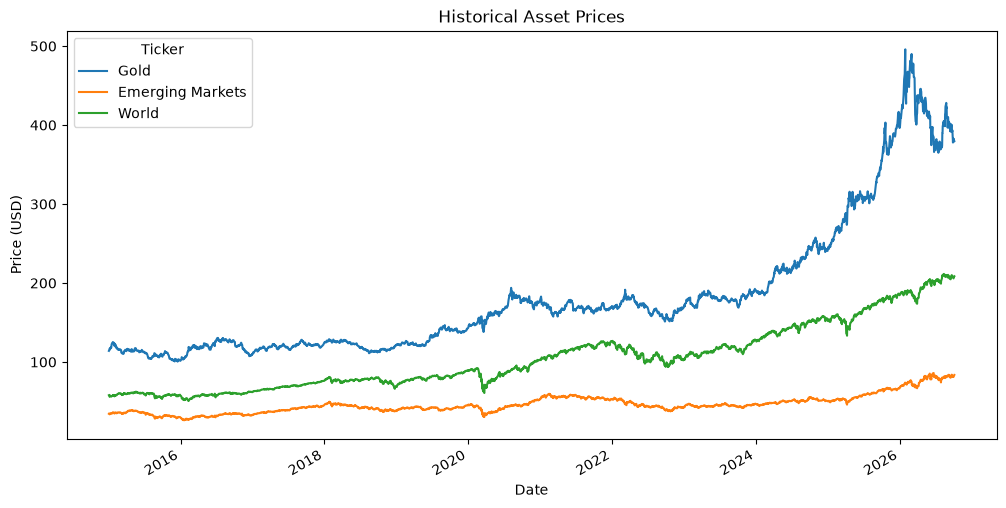

In [24]:
prices_clean.plot(
    figsize=(12, 6),
    title="Historical Asset Prices"
)

plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.show()

In [25]:
returns = prices_clean.pct_change()
returns.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,0.015077,-0.015239,-0.023447
2015-01-06,0.011399,-0.005231,-0.013291
2015-01-07,-0.005891,0.020596,0.010139
2015-01-08,-0.004209,0.017819,0.022225


In [26]:
returns_clean = returns.dropna()
returns_clean.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-05,0.015077,-0.015239,-0.023447
2015-01-06,0.011399,-0.005231,-0.013291
2015-01-07,-0.005891,0.020596,0.010139
2015-01-08,-0.004209,0.017819,0.022225
2015-01-09,0.011385,-0.003586,-0.009538


In [27]:
returns_clean.isnull().sum()

Ticker
Gold                0
Emerging Markets    0
World               0
dtype: int64

In [28]:
prices_clean["World"].head(2)

Date
2015-01-02    57.947815
2015-01-05    56.589088
Name: World, dtype: float64

In [29]:
manual_return = (
    prices_clean["World"].iloc[1] /
    prices_clean["World"].iloc[0]
) - 1

print(manual_return)

-0.023447415624535894


In [30]:
print("Manual:", manual_return)
print("Pandas:", returns_clean["World"].iloc[0])

Manual: -0.023447415624535894
Pandas: -0.023447415624535894


In [31]:
returns_pct=returns_clean * 100
returns_pct.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-05,1.507715,-1.523913,-2.344742
2015-01-06,1.139896,-0.523117,-1.329099
2015-01-07,-0.589141,2.059599,1.013894
2015-01-08,-0.420852,1.781873,2.222535
2015-01-09,1.138520,-0.358584,-0.953848


In [32]:
returns_clean.describe()

Ticker,Gold,Emerging Markets,World
count,2955.000000,2955.000000,2955.000000
mean,0.000460,0.000384,0.000492
std,0.010248,0.012884,0.010761
min,-0.102742,-0.126741,-0.113776
25%,-0.004812,-0.006225,-0.003943
50%,0.000565,0.000691,0.000838
75%,0.005600,0.007506,0.005695
max,0.063587,0.074888,0.090963


In [33]:
daily_volatility = returns_clean.std()
print("Normal daily volatility:", daily_volatility)
print("Percentage:", daily_volatility * 100)

Normal daily volatility: Ticker
Gold                0.010248
Emerging Markets    0.012884
World               0.010761
dtype: float64
Percentage: Ticker
Gold                1.024788
Emerging Markets    1.288390
World               1.076066
dtype: float64


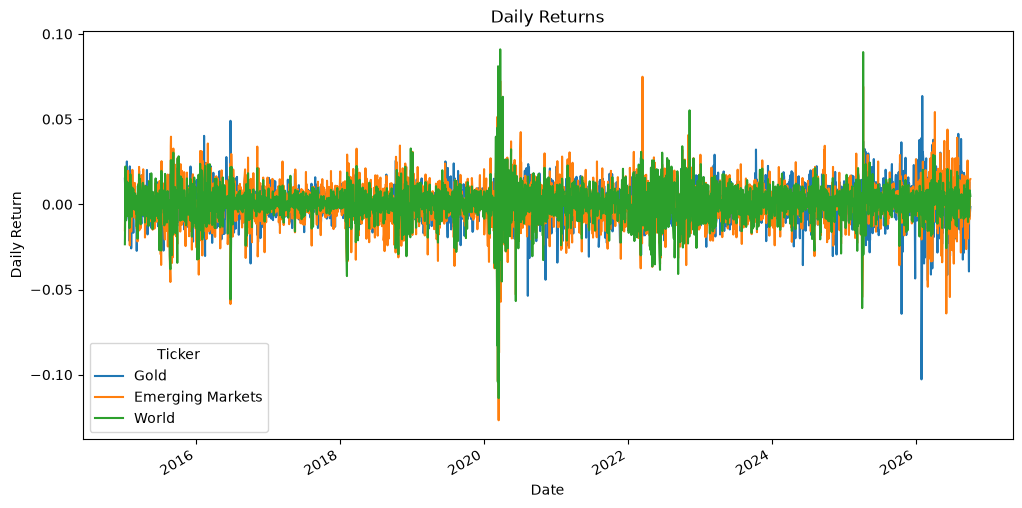

In [34]:
returns_clean.plot(
    figsize=(12, 6),
    title="Daily Returns"
)

plt.ylabel("Daily Return")
plt.xlabel("Date")
plt.show()

In [35]:
cumulative_returns = (1 + returns_clean).cumprod()
cumulative_returns.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-05,1.015077,0.984761,0.976553
2015-01-06,1.026648,0.979609,0.963573
2015-01-07,1.020600,0.999785,0.973343
2015-01-08,1.016304,1.017600,0.994976
2015-01-09,1.027875,1.013951,0.985485


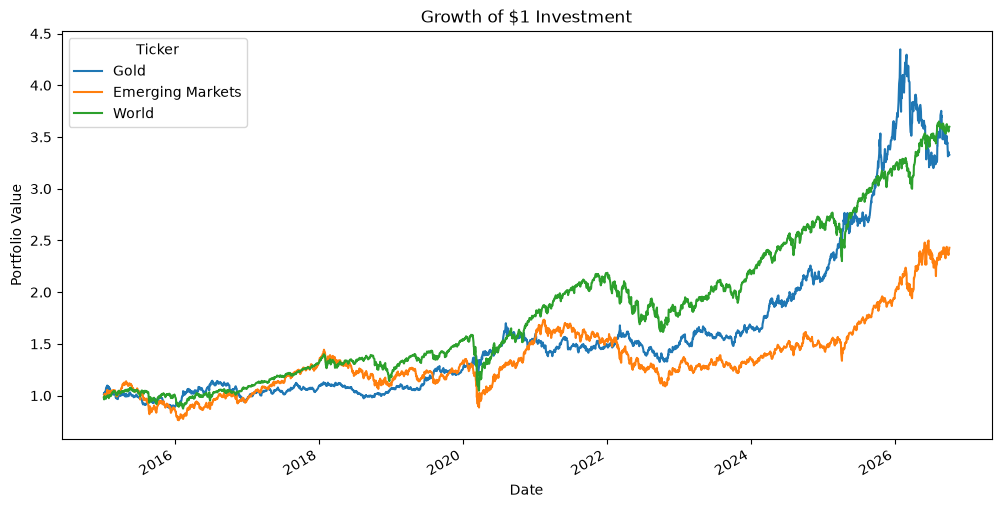

In [36]:
cumulative_returns.plot(
    figsize=(12, 6),
    title="Growth of $1 Investment"
)

plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.show()

In [37]:
cumulative_returns.tail(1)

Ticker,Gold,Emerging Markets,World
Date,,,
2026-10-05,3.327051,2.42931,3.598928


In [38]:
total_returns = (cumulative_returns.iloc[-1] - 1) * 100

print("Total return:", total_returns)

Total return: Ticker
Gold                232.705103
Emerging Markets    142.931006
World               259.892782
Name: 2026-10-05 00:00:00, dtype: float64


In [39]:
start_date = prices_clean.index[0]
end_date = prices_clean.index[-1]

years = (end_date - start_date).days / 365.25

print("Start:", start_date)
print("End:", end_date)
print("Years:", years)

Start: 2015-01-02 00:00:00
End: 2026-10-05 00:00:00
Years: 11.756331279945243


In [40]:
final_values = cumulative_returns.iloc[-1]

cagr = final_values ** (1 / years) - 1

print("CAGR:", cagr * 100)

CAGR: Ticker
Gold                10.766049
Emerging Markets     7.842362
World               11.508608
Name: 2026-10-05 00:00:00, dtype: float64


In [41]:
annual_volatility = returns_clean.std() * np.sqrt(252)

annual_volatility * 100

Ticker
Gold                16.267999
Emerging Markets    20.452554
World               17.082015
dtype: float64

In [42]:
summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "CAGR (%)": cagr * 100,
    "Annual Volatility (%)": annual_volatility * 100
})

summary

,Total Return (%),CAGR (%),Annual Volatility (%)
Ticker,,,
Gold,232.705103,10.766049,16.267999
Emerging Markets,142.931006,7.842362,20.452554
World,259.892782,11.508608,17.082015


In [43]:
correlation_matrix = returns_clean.corr()

correlation_matrix

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,1.000000,0.214277,0.112654
Emerging Markets,0.214277,1.000000,0.803380
World,0.112654,0.803380,1.000000


In [44]:
cov_matrix_daily = returns_clean.cov()

cov_matrix_daily

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,0.000105,0.000028,0.000012
Emerging Markets,0.000028,0.000166,0.000111
World,0.000012,0.000111,0.000116


In [45]:
cov_matrix_annual = cov_matrix_daily * 252

cov_matrix_annual

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,0.026465,0.007129,0.003131
Emerging Markets,0.007129,0.041831,0.028068
World,0.003131,0.028068,0.029180


In [46]:
weights = pd.Series({
    "Gold": 0.10,
    "Emerging Markets": 0.20,
    "World": 0.70
})

weights

Gold                0.1
Emerging Markets    0.2
World               0.7
dtype: float64

In [47]:
portfolio_returns = returns_clean @ weights
portfolio_returns.head()

Date
2015-01-05   -0.017953
2015-01-06   -0.009210
2015-01-07    0.010627
2015-01-08    0.018701
2015-01-09   -0.006256
dtype: float64

In [48]:
type(portfolio_returns)

pandas.Series

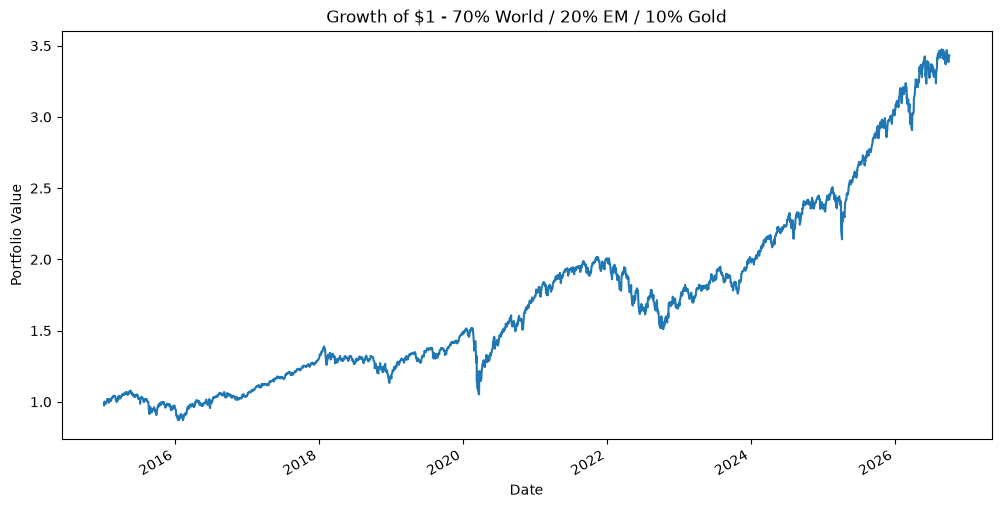

In [49]:
portfolio_growth = (1 + portfolio_returns).cumprod()
portfolio_growth.plot(
    figsize=(12, 6),
    title="Growth of $1 - 70% World / 20% EM / 10% Gold"
)

plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.show()

In [50]:
portfolio_growth.iloc[-1]

np.float64(3.432178218633758)

In [51]:
portfolio_total_return = (portfolio_growth.iloc[-1] - 1) * 100

print("Total Return:", portfolio_total_return)

Total Return: 243.2178218633758


In [52]:
portfolio_cagr = portfolio_growth.iloc[-1] ** (1 / years) - 1

print("CAGR:", portfolio_cagr * 100)

CAGR: 11.059538424145355


In [53]:
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

print("Annual Volatility:", portfolio_volatility * 100)

Annual Volatility: 15.753813637908411


In [54]:
portfolio_variance = weights @ cov_matrix_annual @ weights

portfolio_volatility_matrix = np.sqrt(portfolio_variance)

print(portfolio_volatility_matrix * 100)

15.75381363790841


In [55]:
portfolio_sharpe = portfolio_cagr / portfolio_volatility

print("Portfolio Sharpe:", portfolio_sharpe)

Portfolio Sharpe: 0.7020229309767115


In [56]:
portfolio_summary = pd.Series({
    "Total Return (%)": portfolio_total_return,
    "CAGR (%)": portfolio_cagr * 100,
    "Annual Volatility (%)": portfolio_volatility * 100,
    "Sharpe (Rf=0)": portfolio_sharpe
})

portfolio_summary

Total Return (%)         243.217822
CAGR (%)                  11.059538
Annual Volatility (%)     15.753814
Sharpe (Rf=0)              0.702023
dtype: float64

In [57]:
asset_sharpe = summary["CAGR (%)"] / summary["Annual Volatility (%)"]
asset_sharpe

Ticker
Gold                0.661793
Emerging Markets    0.383442
World               0.673727
dtype: float64

In [58]:
summary["Sharpe (Rf=0)"] = asset_sharpe

summary

,Total Return (%),CAGR (%),Annual Volatility (%),Sharpe (Rf=0)
Ticker,,,,
Gold,232.705103,10.766049,16.267999,0.661793
Emerging Markets,142.931006,7.842362,20.452554,0.383442
World,259.892782,11.508608,17.082015,0.673727


In [59]:
annual_mean_return = returns_clean.mean() * 252

asset_sharpe = annual_mean_return / annual_volatility

asset_sharpe

Ticker
Gold                0.711852
Emerging Markets    0.472941
World               0.725282
dtype: float64

In [60]:
portfolio_annual_mean_return = portfolio_returns.mean() * 252

portfolio_sharpe = (
    portfolio_annual_mean_return /
    portfolio_volatility
)

portfolio_sharpe

np.float64(0.7468095635931362)

In [61]:
annual_mean_return = returns_clean.mean() * 252
annual_mean_return

Ticker
Gold                0.115804
Emerging Markets    0.096728
World               0.123893
dtype: float64

In [62]:
cov_matrix_annual = returns_clean.cov() * 252
cov_matrix_annual

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,0.026465,0.007129,0.003131
Emerging Markets,0.007129,0.041831,0.028068
World,0.003131,0.028068,0.029180


In [63]:
random_weights = np.random.random(3)
random_weights = random_weights / np.sum(random_weights)
random_weights

array([0.47613188, 0.24657453, 0.2772936 ])

In [64]:
random_return = random_weights @ annual_mean_return

random_return

np.float64(0.1133434099639413)

In [65]:
random_volatility = np.sqrt(
    random_weights @ cov_matrix_annual @ random_weights
)

random_volatility

np.float64(0.1308640089878648)

In [66]:
random_sharpe = random_return / random_volatility

random_sharpe

np.float64(0.8661159843762068)

In [67]:
np.random.seed(42)

n_portfolios = 10000

portfolio_results = []

for i in range(n_portfolios):

    weights_random = np.random.random(3)
    weights_random = weights_random / weights_random.sum()

    portfolio_return_random = weights_random @ annual_mean_return

    portfolio_volatility_random = np.sqrt(
        weights_random @ cov_matrix_annual @ weights_random
    )

    portfolio_sharpe_random = (
        portfolio_return_random /
        portfolio_volatility_random
    )

    portfolio_results.append({
        "Gold Weight": weights_random[0],
        "Emerging Markets Weight": weights_random[1],
        "World Weight": weights_random[2],
        "Return": portfolio_return_random,
        "Volatility": portfolio_volatility_random,
        "Sharpe": portfolio_sharpe_random
    })

In [68]:
portfolios = pd.DataFrame(portfolio_results)
portfolios.head()

,Gold Weight,Emerging Markets Weight,World Weight,Return,Volatility,Sharpe
0,0.182059,0.462129,0.355812,0.109867,0.156015,0.704208
1,0.657381,0.171323,0.171296,0.113922,0.132209,0.861680
2,0.038078,0.567845,0.394077,0.108160,0.176131,0.614087
3,0.416865,0.012119,0.571017,0.120192,0.126768,0.948120
4,0.678655,0.173111,0.148234,0.113701,0.133526,0.851525


In [69]:
portfolios.shape

(10000, 6)

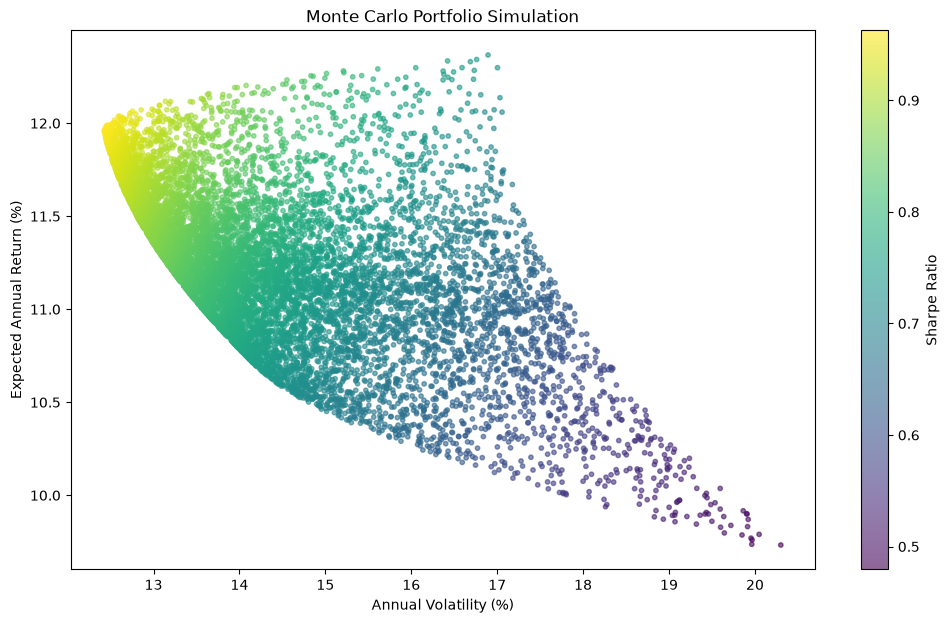

In [70]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.6,
    s=10
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(label="Sharpe Ratio")

plt.show()

In [71]:
max_sharpe_idx = portfolios["Sharpe"].idxmax()
max_sharpe_portfolio = portfolios.loc[max_sharpe_idx]

max_sharpe_portfolio

Gold Weight                0.502177
Emerging Markets Weight    0.002570
World Weight               0.495253
Return                     0.119761
Volatility                 0.124412
Sharpe                     0.962619
Name: 475, dtype: float64

In [72]:
min_vol_idx = portfolios["Volatility"].idxmin()
min_vol_portfolio = portfolios.loc[min_vol_idx]

min_vol_portfolio

Gold Weight                0.527613
Emerging Markets Weight    0.002441
World Weight               0.469946
Return                     0.119559
Volatility                 0.124285
Sharpe                     0.961969
Name: 640, dtype: float64

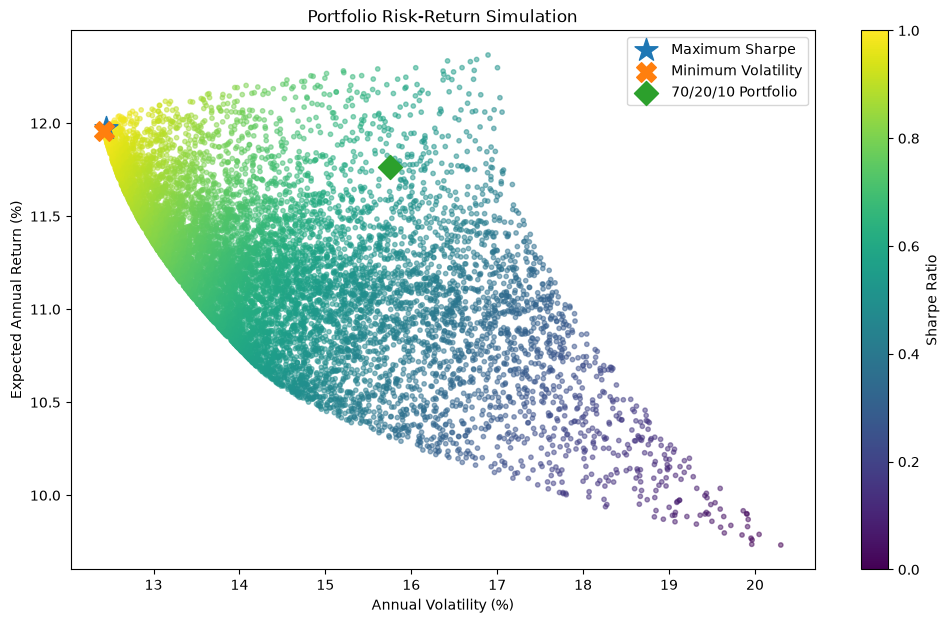

In [73]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.scatter(
    max_sharpe_portfolio["Volatility"] * 100,
    max_sharpe_portfolio["Return"] * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.scatter(
    min_vol_portfolio["Volatility"] * 100,
    min_vol_portfolio["Return"] * 100,
    marker="X",
    s=200,
    label="Minimum Volatility"
)
plt.scatter(
    portfolio_volatility * 100,
    portfolio_annual_mean_return * 100,
    marker="D",
    s=150,
    label="70/20/10 Portfolio"
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Portfolio Risk-Return Simulation")

plt.colorbar(label="Sharpe Ratio")
plt.legend()

plt.show()

In [74]:
print("Maximum Sharpe weights:")
print(
    max_sharpe_portfolio[
        ["Gold Weight", "Emerging Markets Weight", "World Weight"]
    ] * 100
)

print("\nMinimum Volatility weights:")
print(
    min_vol_portfolio[
        ["Gold Weight", "Emerging Markets Weight", "World Weight"]
    ] * 100
)

Maximum Sharpe weights:
Gold Weight                50.217677
Emerging Markets Weight     0.257040
World Weight               49.525283
Name: 475, dtype: float64

Minimum Volatility weights:
Gold Weight                52.761268
Emerging Markets Weight     0.244099
World Weight               46.994633
Name: 640, dtype: float64


In [75]:
print("MAXIMUM SHARPE PORTFOLIO")
print("Return:", max_sharpe_portfolio["Return"] * 100)
print("Volatility:", max_sharpe_portfolio["Volatility"] * 100)
print("Sharpe:", max_sharpe_portfolio["Sharpe"])

print("\nMINIMUM VOLATILITY PORTFOLIO")
print("Return:", min_vol_portfolio["Return"] * 100)
print("Volatility:", min_vol_portfolio["Volatility"] * 100)
print("Sharpe:", min_vol_portfolio["Sharpe"])

MAXIMUM SHARPE PORTFOLIO
Return: 11.976094140435132
Volatility: 12.441161505834561
Sharpe: 0.9626186537984155

MINIMUM VOLATILITY PORTFOLIO
Return: 11.955871367953772
Volatility: 12.42854181259363
Sharpe: 0.961968954060169


In [76]:
from scipy.optimize import minimize

In [77]:
expected_returns = returns_clean.mean() * 252
cov_matrix = returns_clean.cov() * 252
def portfolio_return(weights):
    return weights @ expected_returns.values

def portfolio_volatility(weights):
    return np.sqrt(
        weights @ cov_matrix @ weights
        )

In [78]:
test_weights = np.array([0.5, 0.0, 0.5])

print(portfolio_return(test_weights))
print(portfolio_volatility(test_weights))

0.11984837177256472
0.12440397393003984


In [79]:
n_assets = len(expected_returns)

initial_weights = np.ones(n_assets) / n_assets
initial_weights

array([0.33333333, 0.33333333, 0.33333333])

In [80]:
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

In [81]:
bounds = tuple(
    (0, 1) for _ in range(n_assets)
)

In [82]:
min_vol_result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)
min_vol_result
min_vol_weights = min_vol_result.x

min_vol_weights

array([5.27499552e-01, 1.01915004e-17, 4.72500448e-01])

In [83]:
min_vol_exact = pd.Series(
    min_vol_weights,
    index=returns_clean.columns
)

min_vol_exact * 100

Ticker
Gold                5.274996e+01
Emerging Markets    1.019150e-15
World               4.725004e+01
dtype: float64

In [84]:
print(
    "Return:",
    portfolio_return(min_vol_weights) * 100
)

print(
    "Volatility:",
    portfolio_volatility(min_vol_weights) * 100
)

Return: 11.962593653410249
Volatility: 12.425393071667855


In [85]:
def negative_sharpe(weights):
    portfolio_ret = portfolio_return(weights)
    portfolio_vol = portfolio_volatility(weights)

    
    return -(portfolio_ret / portfolio_vol)

In [86]:
max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)
max_sharpe_weights = max_sharpe_result.x
max_sharpe_exact = pd.Series(
    max_sharpe_weights,
    index=returns_clean.columns
)

max_sharpe_exact * 100

Ticker
Gold                5.063437e+01
Emerging Markets    5.572799e-15
World               4.936563e+01
dtype: float64

In [87]:
max_sharpe_return = portfolio_return(max_sharpe_weights)

max_sharpe_volatility = portfolio_volatility(max_sharpe_weights)

max_sharpe_ratio = (
    max_sharpe_return /
    max_sharpe_volatility
)

In [88]:
print("Weights:")
print(max_sharpe_exact * 100)

print("\nReturn:", max_sharpe_return * 100)

print("Volatility:", max_sharpe_volatility * 100)

print("Sharpe:", max_sharpe_ratio)

Weights:
Ticker
Gold                5.063437e+01
Emerging Markets    5.572799e-15
World               4.936563e+01
dtype: float64

Return: 11.979705953662393
Volatility: 12.434272997865357
Sharpe: 0.9634424108043146


## 8. Efficient Frontier Optimization

In [89]:
def minimize_volatility_for_target(target_return):

    constraints_target = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights: portfolio_return(weights) - target_return
        }
    )

    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_target
    )

    return result

In [90]:
test_target = 0.115

test_result = minimize_volatility_for_target(test_target)

print(test_result.success)

True


In [91]:
test_weights = pd.Series(
    test_result.x,
    index=returns_clean.columns
)

test_weights * 100

Ticker
Gold                53.488743
Emerging Markets    16.809485
World               29.701772
dtype: float64

In [92]:
test_return = portfolio_return(test_result.x)
test_volatility = portfolio_volatility(test_result.x)

print("Return:", test_return * 100)
print("Volatility:", test_volatility * 100)

Return: 11.499999999457552
Volatility: 12.809098642454627


In [93]:
min_vol_return = portfolio_return(min_vol_weights)

print("Minimum Volatility Portfolio Return:", min_vol_return * 100)

Minimum Volatility Portfolio Return: 11.962593653410249


In [94]:
expected_returns

Ticker
Gold                0.115804
Emerging Markets    0.096728
World               0.123893
dtype: float64

In [95]:
returns_clean.mean() * 252

Ticker
Gold                0.115804
Emerging Markets    0.096728
World               0.123893
dtype: float64

In [96]:
max_return = expected_returns.max()

print("Maximum Expected Return:", max_return * 100)

Maximum Expected Return: 12.389271478917987


In [97]:
target_returns = np.linspace(
    min_vol_return,
    max_return,
    50
)

In [98]:
target_returns[:5] * 100

array([11.96259365, 11.97130136, 11.98000907, 11.98871679, 11.9974245 ])

In [99]:
frontier_volatilities = []
frontier_weights = []

In [100]:
for target in target_returns:

    result = minimize_volatility_for_target(target)

    if result.success:
        frontier_volatilities.append(
            portfolio_volatility(result.x)
        )

        frontier_weights.append(
            result.x
        )

In [101]:
print("Target returns:", len(target_returns))
print("Frontier points:", len(frontier_volatilities))

Target returns: 50
Frontier points: 50


In [102]:
frontier_returns = np.array(target_returns)
frontier_volatilities = np.array(frontier_volatilities)

In [103]:
print(type(frontier_returns))
print(type(frontier_volatilities))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


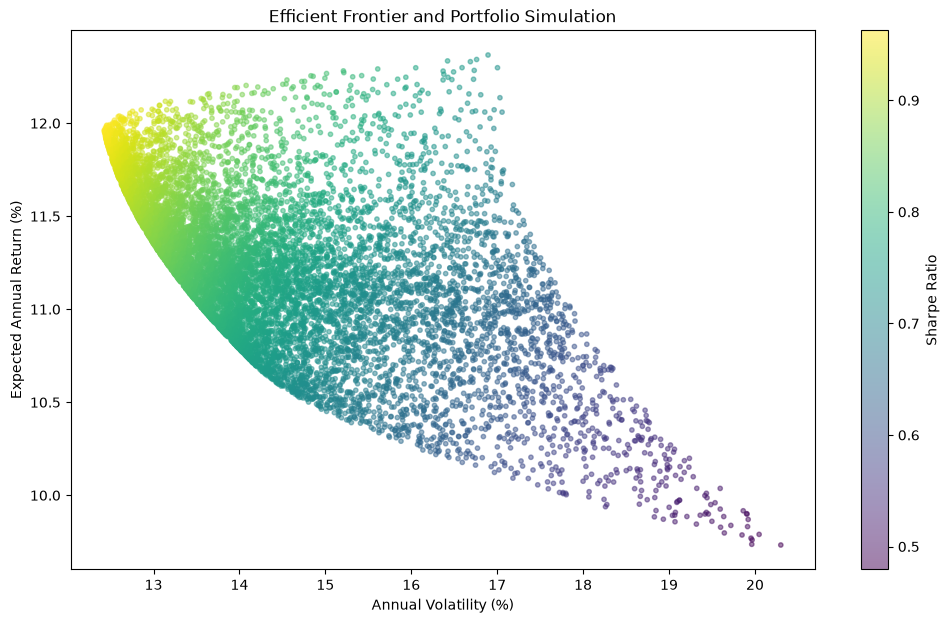

In [104]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Efficient Frontier and Portfolio Simulation")

plt.colorbar(label="Sharpe Ratio")

plt.show()

In [109]:
portfolio_70_20_10_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

portfolio_70_20_10_return = (
    portfolio_returns.mean() * 252
)

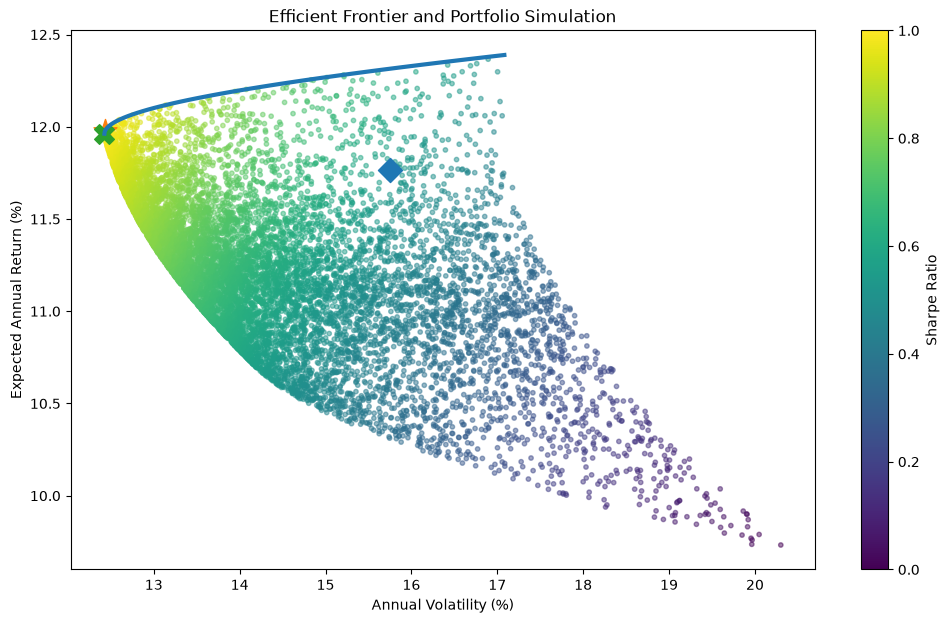

In [110]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.scatter(
    portfolio_70_20_10_volatility * 100,
    portfolio_70_20_10_return * 100,
    marker="D",
    s=150,
    label="70/20/10 Portfolio"
)

plt.scatter(
    max_sharpe_volatility * 100,
    max_sharpe_return * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.scatter(
    portfolio_volatility(min_vol_weights) * 100,
    portfolio_return(min_vol_weights) * 100,
    marker="X",
    s=200,
    label="Minimum Volatility"
)

plt.plot(
    frontier_volatilities * 100,
    frontier_returns * 100,
    linewidth=3,
    label="Efficient Frontier"
)




plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Efficient Frontier and Portfolio Simulation")

plt.colorbar(label="Sharpe Ratio")

plt.show()

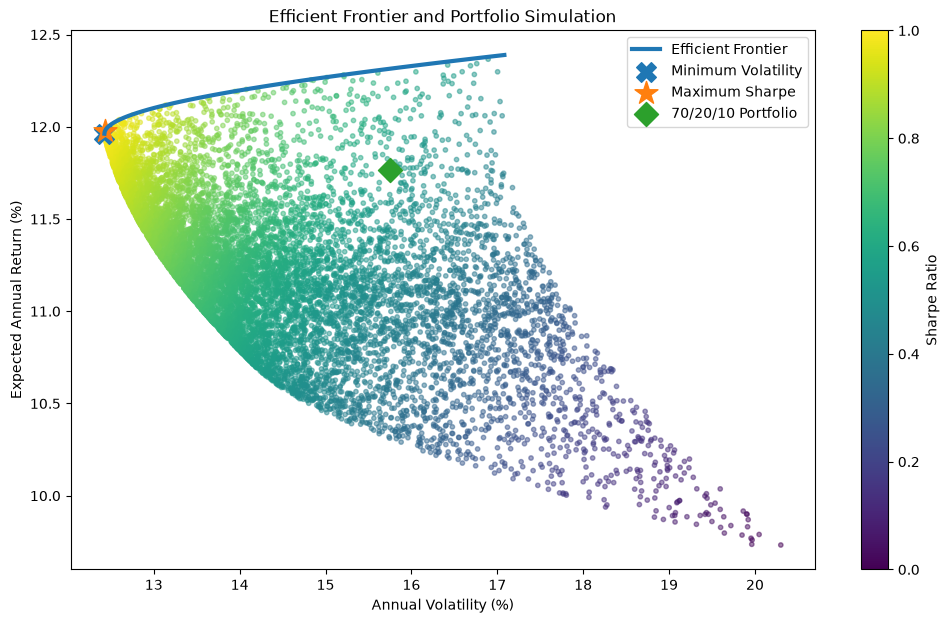

In [111]:
portfolio_70_20_10_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

portfolio_70_20_10_return = (
    portfolio_returns.mean() * 252
)

plt.figure(figsize=(12, 7))

plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.plot(
    frontier_volatilities * 100,
    frontier_returns * 100,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    portfolio_volatility(min_vol_weights) * 100,
    portfolio_return(min_vol_weights) * 100,
    marker="X",
    s=200,
    label="Minimum Volatility"
)

plt.scatter(
    max_sharpe_volatility * 100,
    max_sharpe_return * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.scatter(
    portfolio_70_20_10_volatility * 100,
    portfolio_70_20_10_return * 100,
    marker="D",
    s=150,
    label="70/20/10 Portfolio"
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Efficient Frontier and Portfolio Simulation")

plt.colorbar(label="Sharpe Ratio")
plt.legend()

plt.show()